<a href="https://colab.research.google.com/github/auliatauhid/Data-Science-2026/blob/main/Pertemuan5_AuliaTauhid_250401020136.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

(53940, 10) carat       float64
cut        category
color      category
clarity    category
depth       float64
table       float64
price         int64
x           float64
y           float64
z           float64
dtype: object
          carat     depth     table     price         x         y         z
count  53940.00  53940.00  53940.00  53940.00  53940.00  53940.00  53940.00
mean       0.80     61.75     57.46   3932.80      5.73      5.73      3.54
std        0.47      1.43      2.23   3989.44      1.12      1.14      0.71
min        0.20     43.00     43.00    326.00      0.00      0.00      0.00
25%        0.40     61.00     56.00    950.00      4.71      4.72      2.91
50%        0.70     61.80     57.00   2401.00      5.70      5.71      3.53
75%        1.04     62.50     59.00   5324.25      6.54      6.54      4.04
max        5.01     79.00     95.00  18823.00     10.74     58.90     31.80


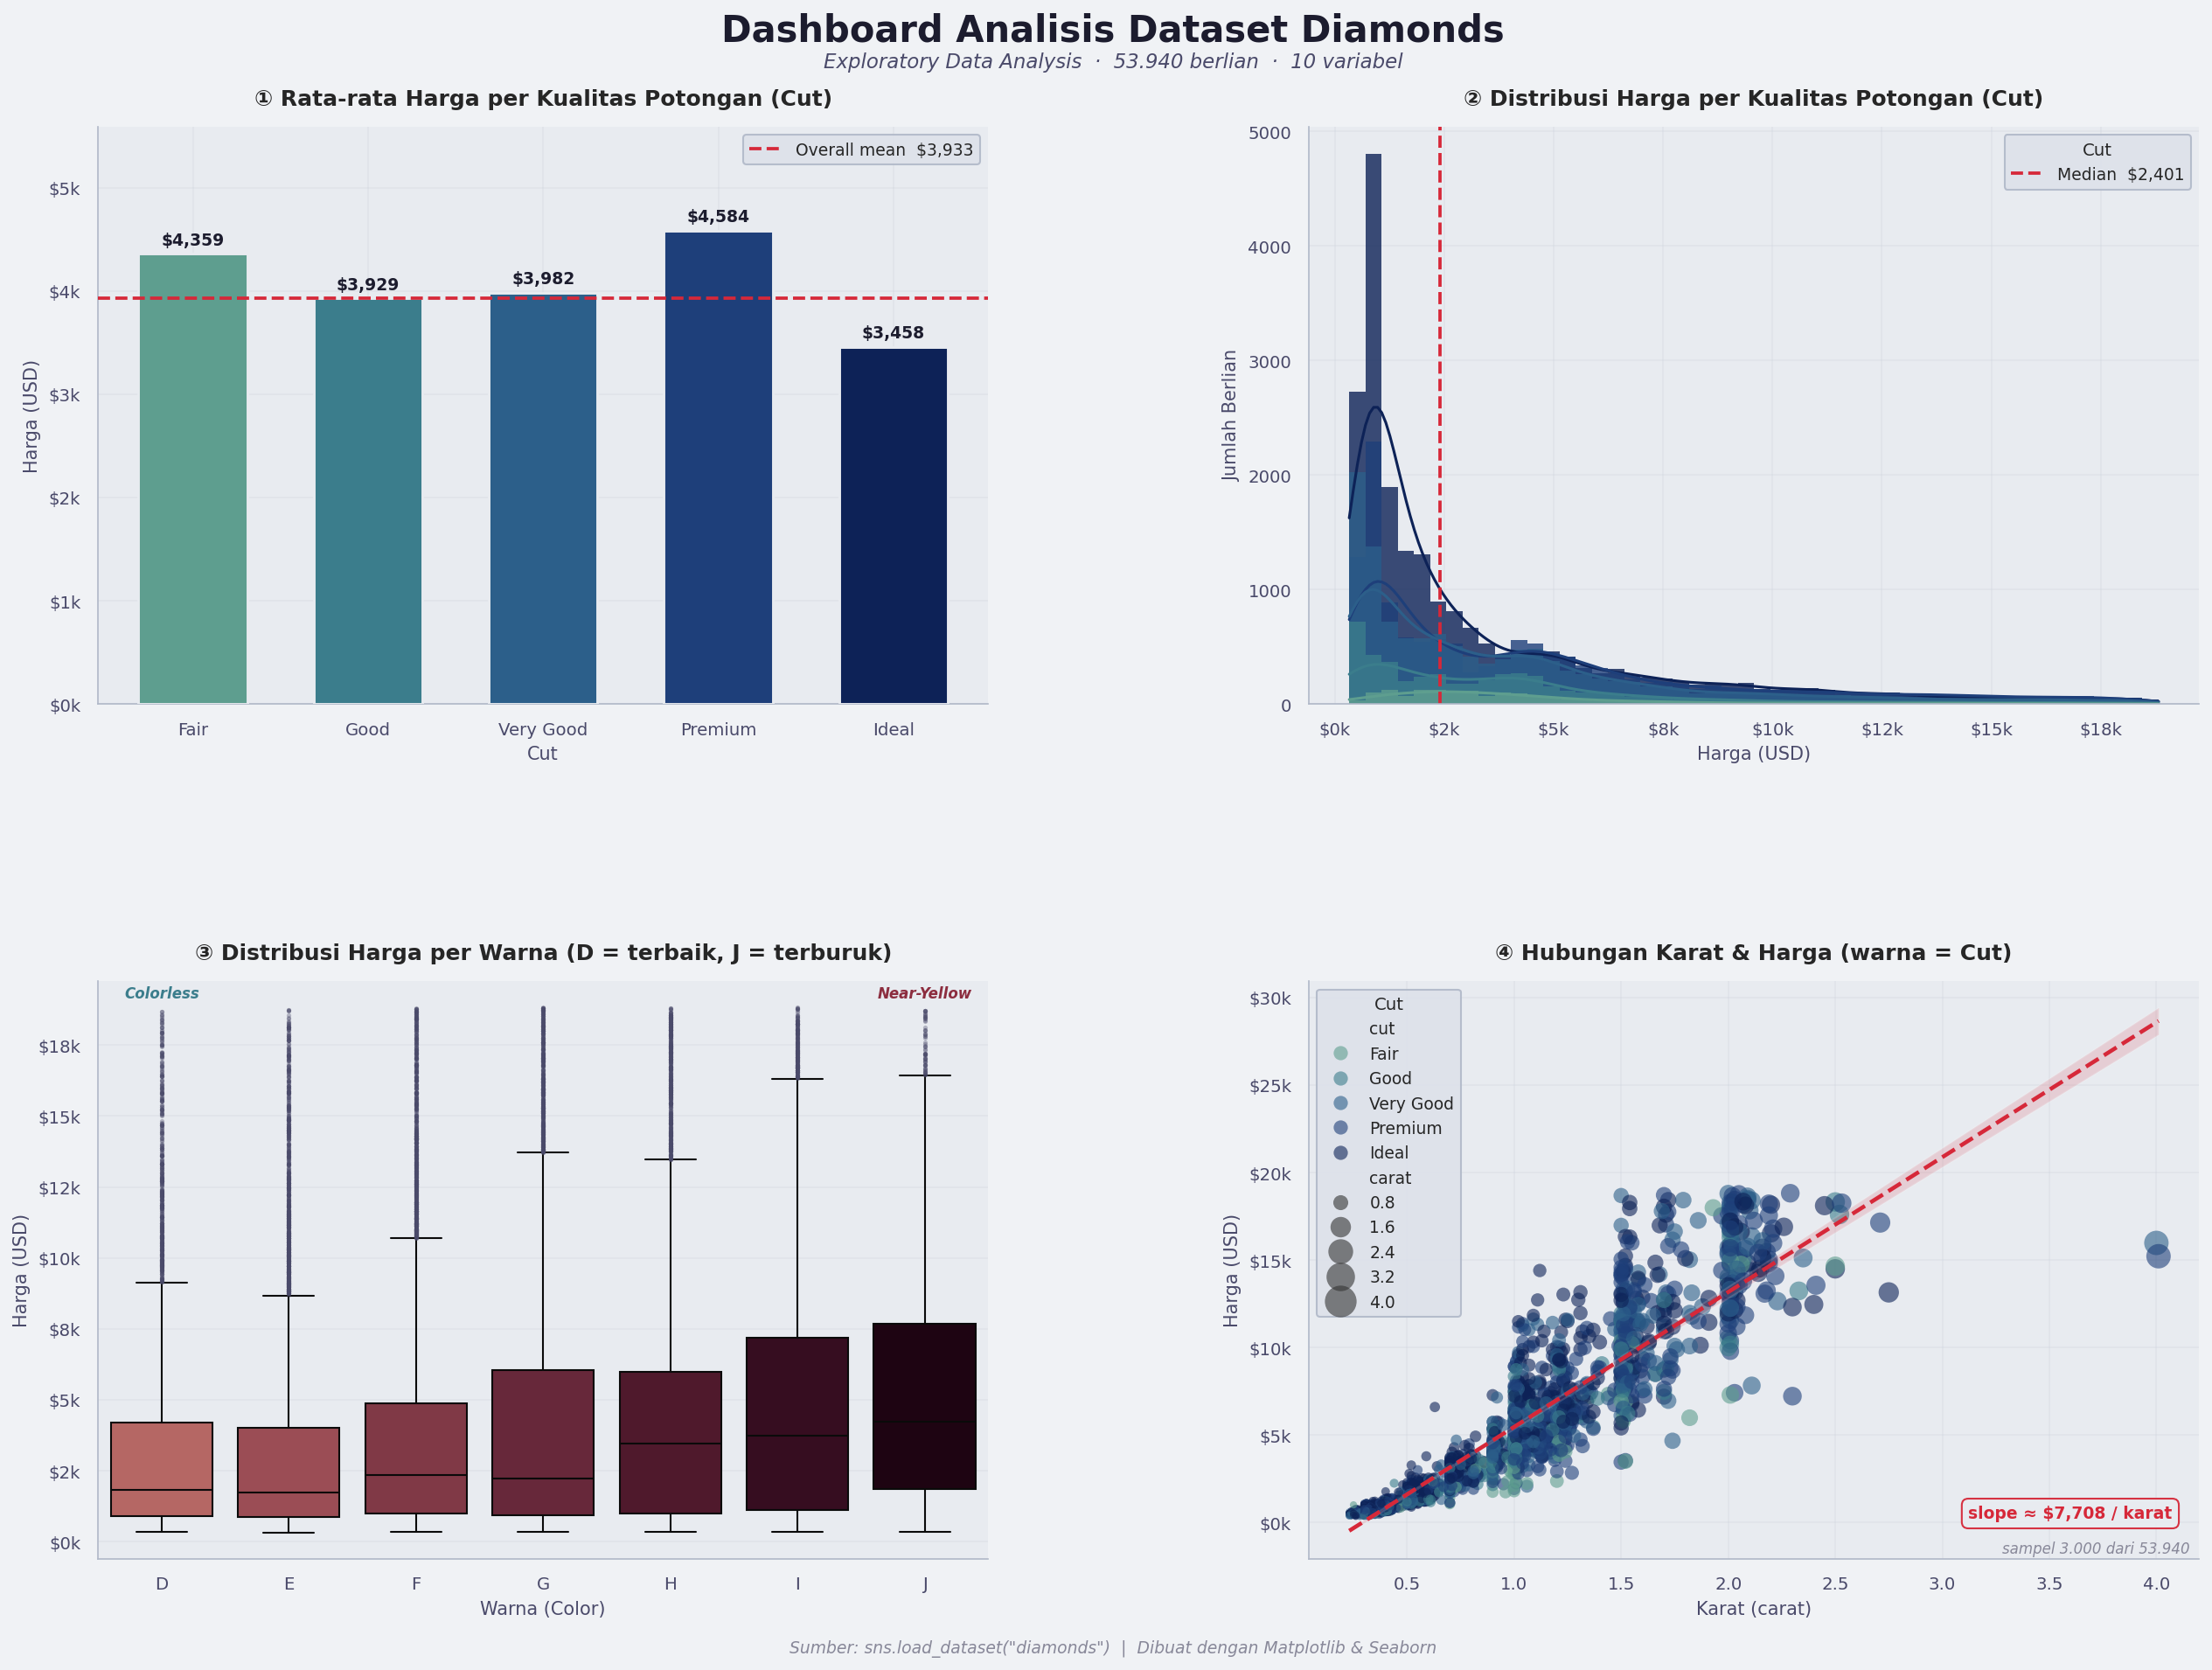

Dashboard tersimpan sebagai dashboard_diamonds.png


In [6]:
# ── DASHBOARD VISUALISASI STATIS: DIAMONDS ─────────────────────────────
import pandas as pd, numpy as np
import matplotlib.pyplot as plt, matplotlib.gridspec as gridspec
import seaborn as sns

# ── 1. LOAD & INSPECT DATASET ──────────────────────────────────────────
df = sns.load_dataset('diamonds')
print(df.shape, df.dtypes)
print(df.describe().round(2))

# ── GLOBAL STYLE ───────────────────────────────────────────────────────
BG        = '#F0F2F5'   # background figure
PANEL_BG  = '#E8EBF0'   # background tiap panel (bukan putih)
GRID_CLR  = '#CDD2DB'   # warna grid
TEXT_DARK = '#1C1C2E'
TEXT_MID  = '#4A4A6A'
TEXT_LITE = '#888899'
ACCENT    = '#D62839'   # merah untuk garis referensi

sns.set_theme(style='whitegrid', font_scale=1.05)
plt.rcParams.update({
    'font.family':           'DejaVu Sans',
    'axes.facecolor':        PANEL_BG,
    'axes.titlesize':        12,
    'axes.titleweight':      'bold',
    'axes.titlepad':         12,
    'axes.labelsize':        10,
    'axes.labelcolor':       TEXT_MID,
    'axes.edgecolor':        '#B0B8C8',
    'axes.linewidth':        0.8,
    'xtick.labelsize':       9.5,
    'ytick.labelsize':       9.5,
    'xtick.color':           TEXT_MID,
    'ytick.color':           TEXT_MID,
    'grid.color':            GRID_CLR,
    'grid.linewidth':        0.8,
    'legend.fontsize':       9,
    'legend.title_fontsize': 9.5,
    'legend.framealpha':     0.9,
    'legend.facecolor':      '#DDE1EA',
    'legend.edgecolor':      '#B0B8C8',
    'figure.dpi':            150,
})

CUT_ORDER   = ['Fair', 'Good', 'Very Good', 'Premium', 'Ideal']
COLOR_ORDER = ['D', 'E', 'F', 'G', 'H', 'I', 'J']

# Palet — semua warna cukup gelap agar kontras di atas PANEL_BG
CUT_PALETTE   = ['#5E9E8F', '#3B7D8C', '#2C5F8A', '#1E3F7A', '#0D2257']
COLOR_PALETTE = ['#C25B56', '#A8404A', '#8C2D3F', '#721D35', '#581029',
                 '#3D0620', '#220013']

def fmt_usd(ax, axis='y'):
    fmt = plt.FuncFormatter(lambda x, _: f'${x/1000:.0f}k')
    if axis == 'y':
        ax.yaxis.set_major_formatter(fmt)
    else:
        ax.xaxis.set_major_formatter(fmt)

def clean_spines(ax):
    ax.spines[['top', 'right']].set_visible(False)
    ax.spines[['left', 'bottom']].set_color('#B0B8C8')

# ── 2. SETUP FIGURE LAYOUT ─────────────────────────────────────────────
fig = plt.figure(figsize=(18, 13))
fig.patch.set_facecolor(BG)

fig.text(0.5, 0.977, 'Dashboard Analisis Dataset Diamonds',
         ha='center', va='top', fontsize=20, fontweight='bold', color=TEXT_DARK)
fig.text(0.5, 0.954, 'Exploratory Data Analysis  ·  53.940 berlian  ·  10 variabel',
         ha='center', va='top', fontsize=11, color=TEXT_MID, style='italic')

line_ax = fig.add_axes([0.05, 0.947, 0.90, 0.0015])
line_ax.set_facecolor('#B0B8C8')
line_ax.axis('off')

gs = gridspec.GridSpec(2, 2, figure=fig,
                       hspace=0.48, wspace=0.36,
                       left=0.07, right=0.96,
                       top=0.91, bottom=0.07)
ax1 = fig.add_subplot(gs[0, 0])
ax2 = fig.add_subplot(gs[0, 1])
ax3 = fig.add_subplot(gs[1, 0])
ax4 = fig.add_subplot(gs[1, 1])

# ── 3. GRAFIK 1: Bar Chart ─────────────────────────────────────────────
avg_by_cut = (df.groupby('cut', observed=False)['price']
                .mean().reindex(CUT_ORDER))

bars = ax1.bar(CUT_ORDER, avg_by_cut.values,
               color=CUT_PALETTE, edgecolor=PANEL_BG, linewidth=1.4,
               width=0.62, zorder=3)

for bar, val in zip(bars, avg_by_cut.values):
    ax1.text(bar.get_x() + bar.get_width() / 2,
             bar.get_height() + 55,
             f'${val:,.0f}',
             ha='center', va='bottom', fontsize=9,
             fontweight='bold', color=TEXT_DARK)

grand_mean = df['price'].mean()
ax1.axhline(grand_mean, color=ACCENT, linestyle='--',
            linewidth=1.8, zorder=4,
            label=f'Overall mean  ${grand_mean:,.0f}')
ax1.legend(loc='upper right')
ax1.set_title('① Rata-rata Harga per Kualitas Potongan (Cut)')
ax1.set_xlabel('Cut')
ax1.set_ylabel('Harga (USD)')
ax1.set_ylim(0, avg_by_cut.max() * 1.22)
ax1.tick_params(axis='x', rotation=0)
fmt_usd(ax1)
clean_spines(ax1)

# ── 4. GRAFIK 2: Histogram + KDE ───────────────────────────────────────
sns.histplot(data=df, x='price', hue='cut',
             hue_order=CUT_ORDER, kde=True,
             palette=CUT_PALETTE,
             bins=50, alpha=0.80, linewidth=0,
             ax=ax2)

med = df['price'].median()
ax2.axvline(med, color=ACCENT, linewidth=1.8, linestyle='--',
            label=f'Median  ${med:,.0f}')
ax2.legend(title='Cut', loc='upper right')
ax2.set_title('② Distribusi Harga per Kualitas Potongan (Cut)')
ax2.set_xlabel('Harga (USD)')
ax2.set_ylabel('Jumlah Berlian')
fmt_usd(ax2, axis='x')
clean_spines(ax2)

# ── 5. GRAFIK 3: Boxplot ───────────────────────────────────────────────
sns.boxplot(data=df, x='color', y='price',
            order=COLOR_ORDER,
            hue='color', hue_order=COLOR_ORDER,
            palette=COLOR_PALETTE,
            legend=False,
            linewidth=1.0,
            flierprops=dict(marker='o', markersize=2.5,
                            markerfacecolor=TEXT_MID,
                            markeredgewidth=0, alpha=0.35),
            ax=ax3)

ax3.set_title('③ Distribusi Harga per Warna (D = terbaik, J = terburuk)')
ax3.set_xlabel('Warna (Color)')
ax3.set_ylabel('Harga (USD)')
fmt_usd(ax3)
clean_spines(ax3)

ymax = ax3.get_ylim()[1]
ax3.text(0,   ymax * 0.97, 'Colorless',   ha='center', fontsize=8,
         color='#3B7D8C', style='italic', fontweight='bold')
ax3.text(6,   ymax * 0.97, 'Near-Yellow', ha='center', fontsize=8,
         color='#8C2D3F', style='italic', fontweight='bold')

# ── 6. GRAFIK 4: Scatter Plot ──────────────────────────────────────────
sample = df.sample(3000, random_state=42)

sns.scatterplot(data=sample, x='carat', y='price',
                hue='cut', hue_order=CUT_ORDER,
                size='carat', sizes=(15, 180),
                palette=CUT_PALETTE,
                alpha=0.60, edgecolor='none',
                ax=ax4)

sns.regplot(data=sample, x='carat', y='price',
            scatter=False, color=ACCENT,
            line_kws={'linewidth': 2.2, 'linestyle': '--'},
            ax=ax4)

z = np.polyfit(sample['carat'], sample['price'], 1)
ax4.text(0.97, 0.07,
         f'slope ≈ ${z[0]:,.0f} / karat',
         transform=ax4.transAxes, ha='right', fontsize=9,
         color=ACCENT, fontweight='bold',
         bbox=dict(facecolor=PANEL_BG, edgecolor=ACCENT,
                   alpha=0.95, boxstyle='round,pad=0.4'))

ax4.set_title('④ Hubungan Karat & Harga (warna = Cut)')
ax4.set_xlabel('Karat (carat)')
ax4.set_ylabel('Harga (USD)')
ax4.legend(title='Cut', loc='upper left', markerscale=1.3)
fmt_usd(ax4)
clean_spines(ax4)
ax4.text(0.99, 0.01, 'sampel 3.000 dari 53.940',
         transform=ax4.transAxes, ha='right',
         fontsize=8, color=TEXT_LITE, style='italic')

# ── Footer ─────────────────────────────────────────────────────────────
fig.text(0.5, 0.015,
         'Sumber: sns.load_dataset("diamonds")  |  Dibuat dengan Matplotlib & Seaborn',
         ha='center', fontsize=9, color=TEXT_LITE, style='italic')

# ── 7. EKSPOR ──────────────────────────────────────────────────────────
plt.savefig('dashboard_diamonds.png', dpi=150, bbox_inches='tight',
            facecolor=fig.get_facecolor())
plt.show()
print('Dashboard tersimpan sebagai dashboard_diamonds.png')